# Task 3

Build a Decision Tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioral data. Using dataset  Bank Marketing datset from the UCI Machine Learning Repository.

#Import Libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading Dataset

In [7]:
df=pd.read_csv("/content/bank-additional-full.csv",sep=";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29537,50,blue-collar,married,basic.9y,no,no,no,cellular,apr,mon,...,3,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
29538,42,management,single,university.degree,unknown,no,yes,cellular,apr,mon,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
29539,36,technician,married,high.school,no,yes,yes,cellular,apr,mon,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
29540,50,services,married,high.school,no,yes,no,cellular,apr,mon,...,6,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no


#Understanding dataset

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29542 entries, 0 to 29541
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             29542 non-null  int64  
 1   job             29542 non-null  object 
 2   marital         29542 non-null  object 
 3   education       29542 non-null  object 
 4   default         29542 non-null  object 
 5   housing         29542 non-null  object 
 6   loan            29542 non-null  object 
 7   contact         29542 non-null  object 
 8   month           29542 non-null  object 
 9   day_of_week     29542 non-null  object 
 10  duration        29542 non-null  int64  
 11  campaign        29542 non-null  int64  
 12  pdays           29542 non-null  int64  
 13  previous        29542 non-null  int64  
 14  poutcome        29542 non-null  object 
 15  emp.var.rate    29542 non-null  float64
 16  cons.price.idx  29542 non-null  float64
 17  cons.conf.idx   29542 non-null 

We have 41188 rows and 21 columns.

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000,29542.000000
mean,40.158351,255.042414,2.746666,996.914325,0.042143,0.933011,93.792315,-39.968797,4.606524,5206.219484
std,9.313604,263.685440,3.083209,45.480303,0.208688,0.853768,0.426351,3.512002,0.858287,32.514242
min,18.000000,0.000000,1.000000,0.000000,0.000000,-1.800000,92.756000,-50.000000,1.405000,5099.100000
25%,33.000000,99.000000,1.000000,999.000000,0.000000,1.100000,93.444000,-42.700000,4.856000,5191.000000
50%,39.000000,173.000000,2.000000,999.000000,0.000000,1.400000,93.918000,-41.800000,4.955000,5228.100000
75%,47.000000,312.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.962000,5228.100000
max,95.000000,4918.000000,56.000000,999.000000,3.000000,1.400000,94.465000,-36.100000,5.045000,5228.100000


In [11]:
df.shape

(29542, 21)

We have 41188 rows and 21 columns.

# Exploratory Data Analysis

In [12]:
#Finding missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


So here we can see there is no missing values.

#Histogram

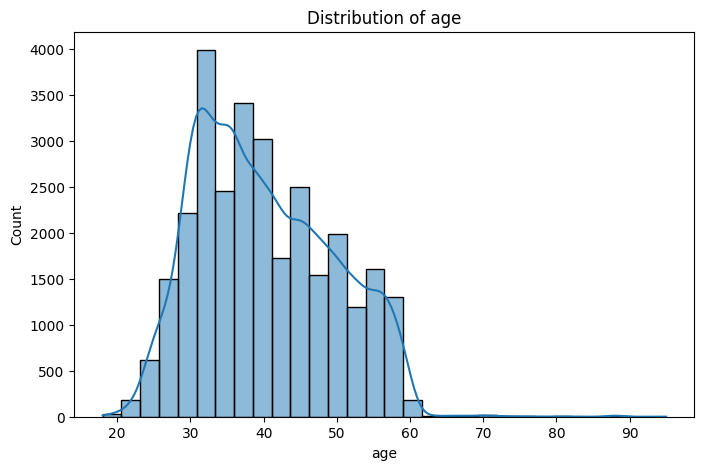

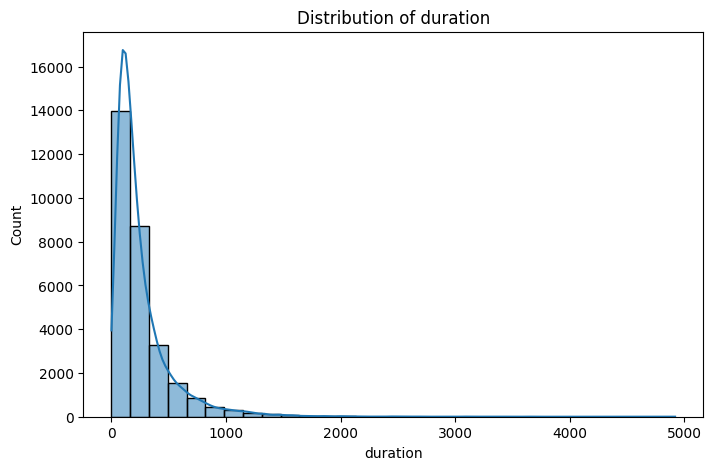

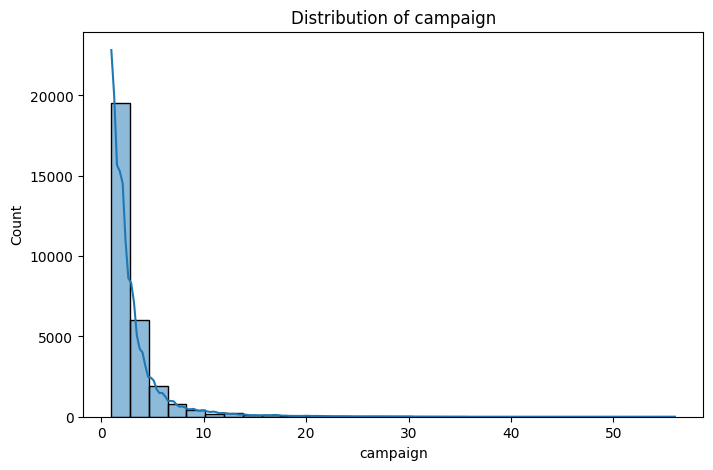

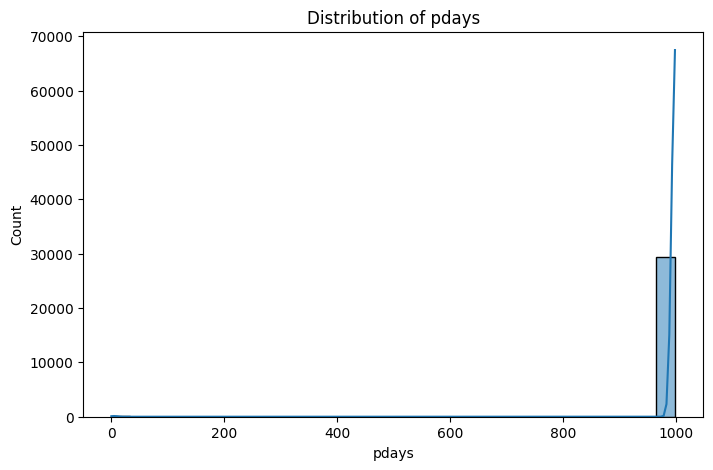

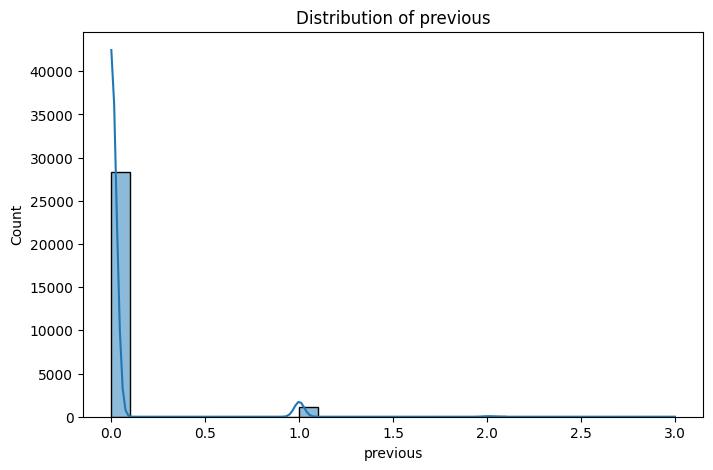

In [13]:
numeric_cols = ['age','duration', 'campaign', 'pdays', 'previous']
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Bar char of age suggests marketing campaigns mostly reached working-age individuals.
Bar chart of duration says Longer calls usually increase the chance of purchase, so this is an important predictor.
Bar chart of campaign suggest too many contacts may indicate customer fatigue (less chance of success).
Bar chart of pdays we see many values are 999, meaning the customer was not previously contacted.Actual values (for those previously contacted) cluster at smaller numbers.
Bar chart of previos says majority have 0 previous contacts, meaning many customers were new in the campaign.

/tmp/ipython-input-2858632823.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='job', data=df, order=df['job'].value_counts().index, palette="viridis")


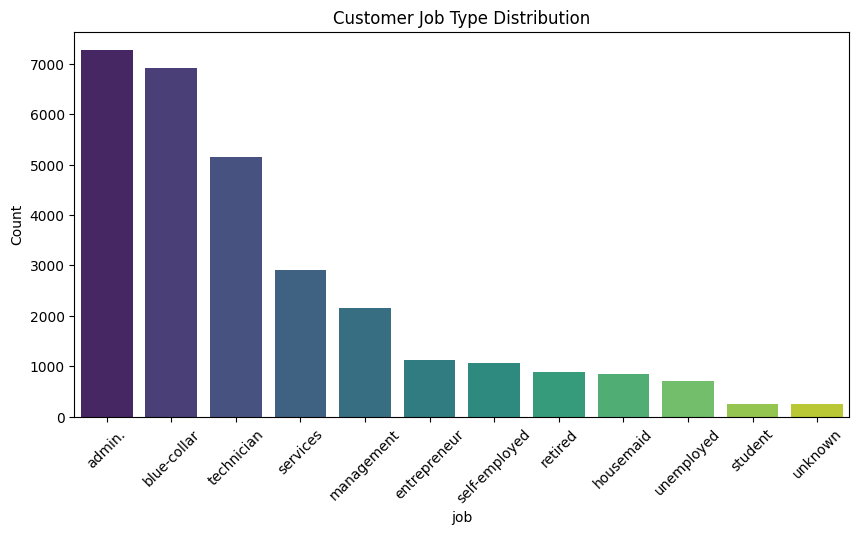

In [14]:
#Bar Charts - Categorical Variables
#Job type distribution
plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df, order=df['job'].value_counts().index, palette="viridis")
plt.title("Customer Job Type Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-2682876289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette="coolwarm")


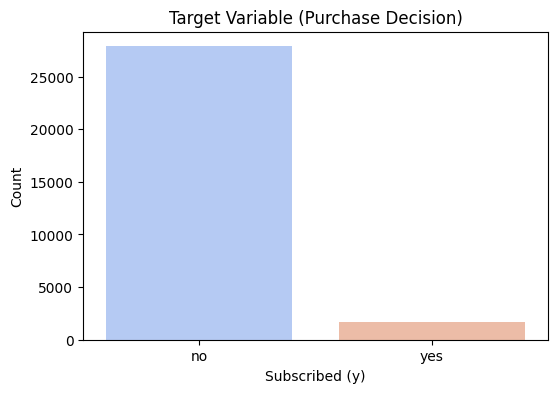

In [15]:
#Target variable distribution

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df, palette="coolwarm")
plt.title("Target Variable (Purchase Decision)")
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
plt.show()

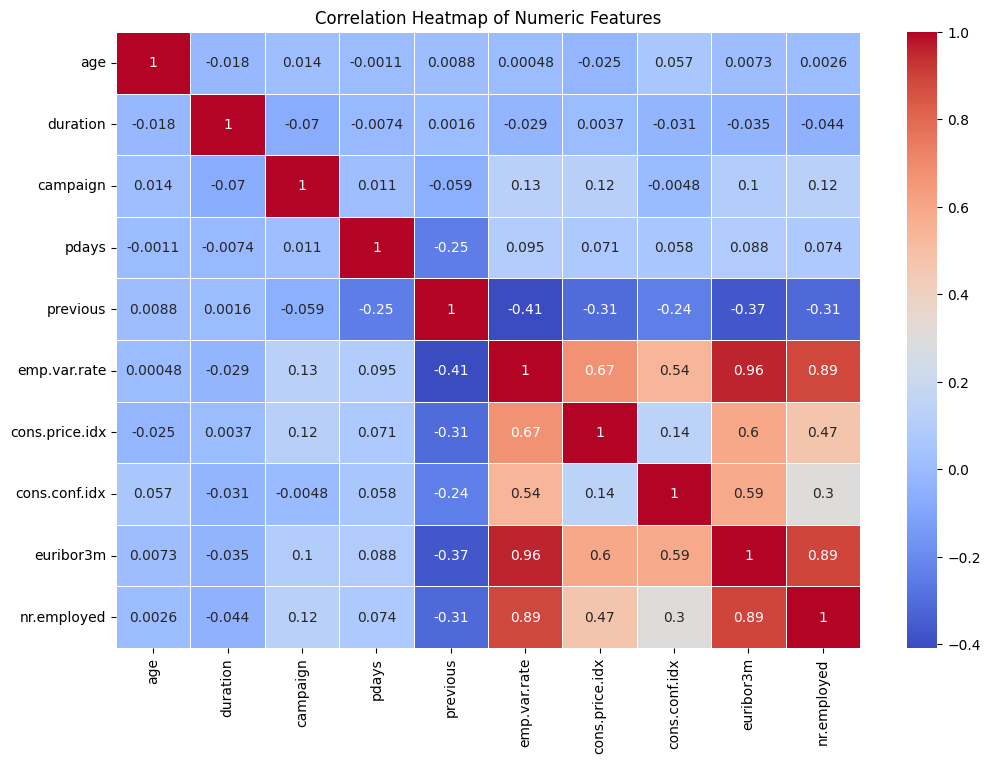

In [16]:
#Correlation Heatmap - Numeric Features

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Data Preprocessing

In [17]:
# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

In [18]:
# Encode categorical features (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

In [19]:
# Encode target variable (yes=1, no=0)
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# Build the Decision Tree Model

In [21]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Make Predictions

In [22]:
y_pred = dt.predict(X_test)


#Evaluate the Model

In [23]:
#Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9503554101320095

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      8363
           1       0.58      0.42      0.49       500

    accuracy                           0.95      8863
   macro avg       0.77      0.70      0.73      8863
weighted avg       0.94      0.95      0.95      8863



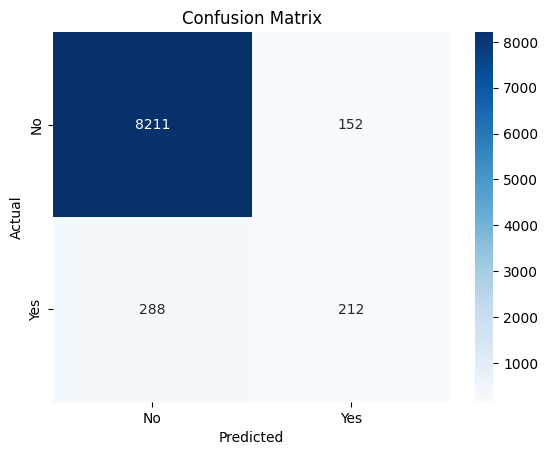

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_smote))

# Train Decision Tree on balanced dataset
dt_smote = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_smote = dt_smote.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))


Before SMOTE: [19512  1167]
After SMOTE: [19512 19512]
Accuracy: 0.8752115536500057

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93      8363
           1       0.30      0.93      0.46       500

    accuracy                           0.88      8863
   macro avg       0.65      0.90      0.69      8863
weighted avg       0.96      0.88      0.90      8863



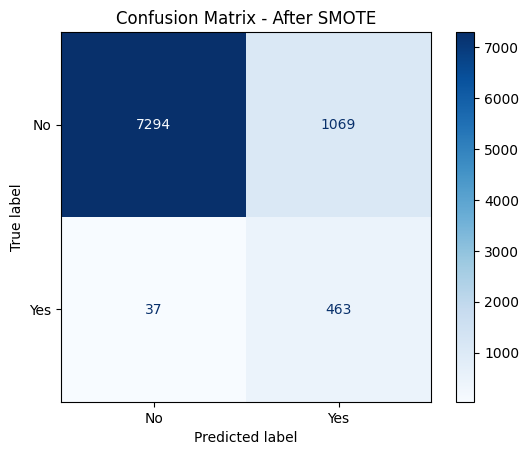

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - After SMOTE")
plt.show()


Top-left: Correctly predicted “No Purchase”.

Top-right: Predicted “Yes” but actually “No” (false alarms).

Bottom-left: Predicted “No” but actually “Yes” (missed buyers).

Bottom-right: Correctly predicted “Yes Purchase”.

#Visualize the Decision Tree

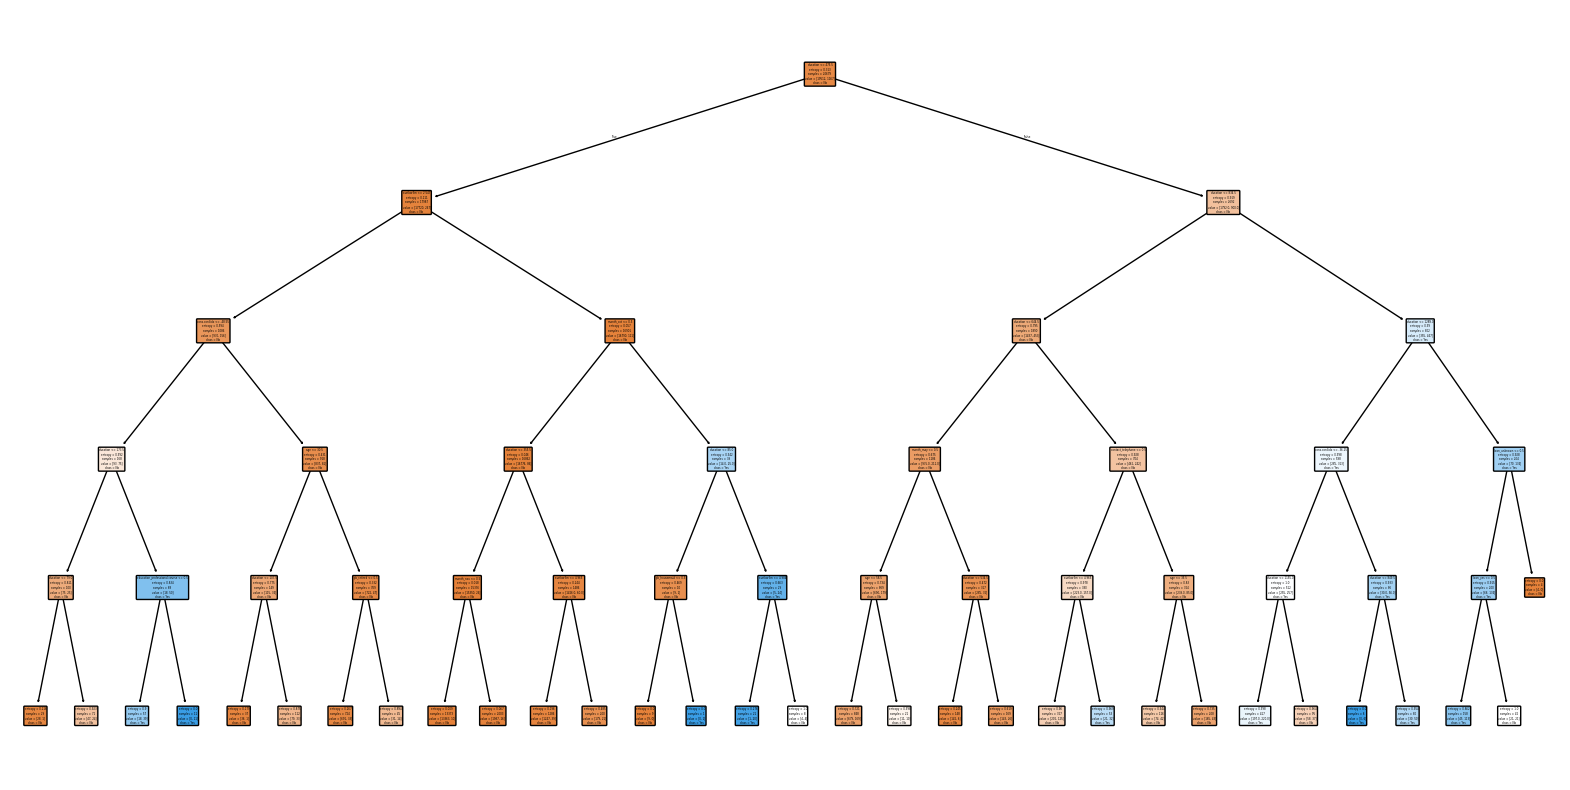

In [27]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.show()

#Feature Importance

In [28]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:\n", feat_imp.head(10))


Top 10 Important Features:
               Feature  Importance
1            duration    0.756594
8           euribor3m    0.129963
45          month_oct    0.046058
7       cons.conf.idx    0.027118
0                 age    0.011370
44          month_nov    0.007460
14        job_retired    0.006620
43          month_may    0.004291
37  contact_telephone    0.003979
35       loan_unknown    0.001942


#Hyperparameter Tuning

In [29]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9485469607703264


In [32]:
#Evaluate the Tuned Model
best_model = grid.best_estimator_   # or random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(" Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\n Classification Report:\n", classification_report(y_test, y_pred_tuned))


 Accuracy: 0.9494527812253187

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      8363
           1       0.58      0.39      0.47       500

    accuracy                           0.95      8863
   macro avg       0.77      0.69      0.72      8863
weighted avg       0.94      0.95      0.94      8863



#Save Final Model

In [31]:
import joblib
joblib.dump(best_model, "final_decision_tree.pkl")
print("✅ Final tuned model saved as 'final_decision_tree.pkl'")

✅ Final tuned model saved as 'final_decision_tree.pkl'
